# PD-regulation

$l_{crit} = \text{const}$ and $dt_{\text{update action}} = \text{const}$, so 

$$
    \begin{aligned}
        & \frac{dx_{jet}}{dt} = v_{jet} \\
        & \frac{dx^{rel}_{jet}}{dt} = v^{rel}_{jet} \\
    \end{aligned}
$$

Error $e=(1-x^{rel}_{jet})$, then

$$
    \frac{de}{dt} = - v^{rel}_{jet}
$$

In [1]:
import numpy as np
import random
import os
import matplotlib.pyplot as plt

from datetime import datetime

from src.scenario_v0 import SimulationScenario
from src.system_v0 import HydraulicSystem
from src.simulator_v0 import Simulator
from src.policy_v0 import PDController

data_path = './data/P_controller'
os.path.isdir(data_path)
%matplotlib inline

# PD-controller seeds

Time start: 2025-09-03_194903
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

SEED = 1
Total objective: 1.93293
log folder: ./data/P_controller/2025-09-03_194903_3_state_seed_1


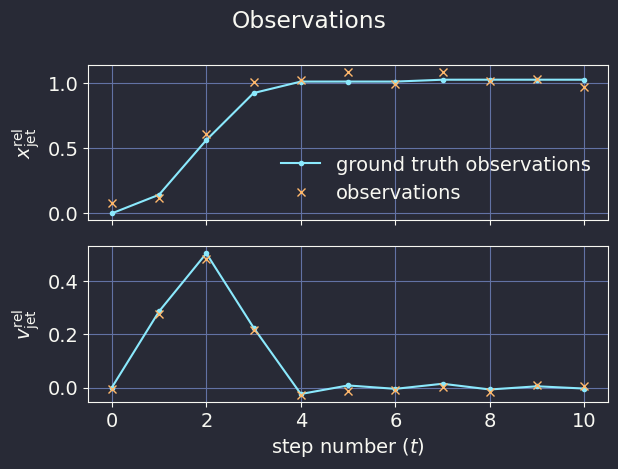

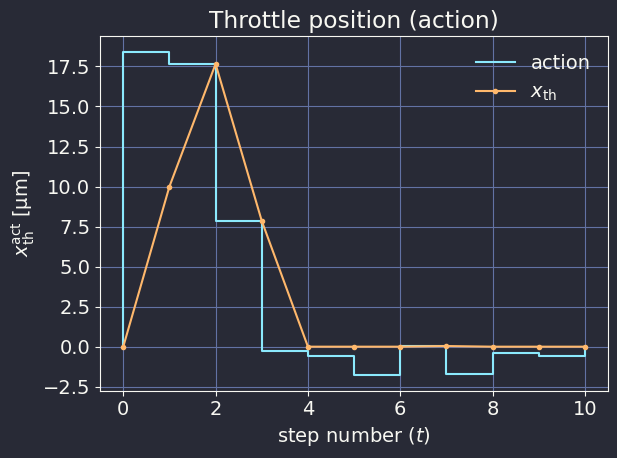


SEED = 2
Total objective: 2.04416
log folder: ./data/P_controller/2025-09-03_194903_3_state_seed_2


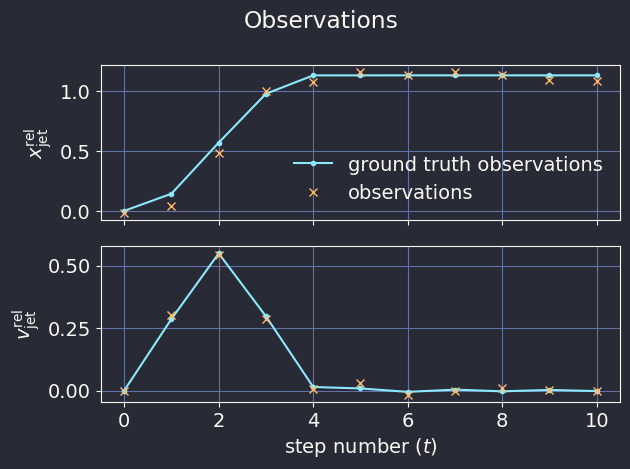

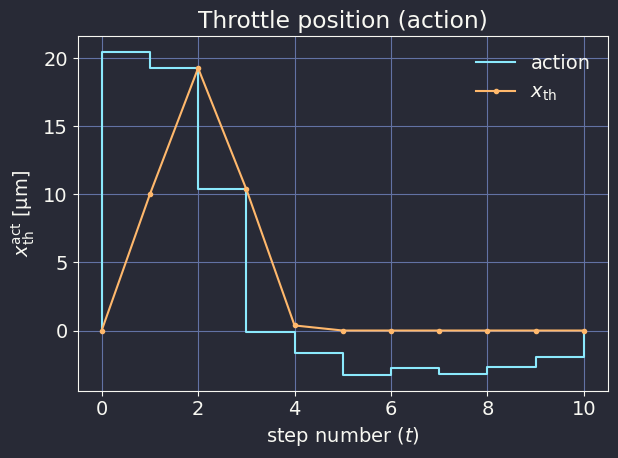


SEED = 3
Total objective: 1.95609
log folder: ./data/P_controller/2025-09-03_194903_3_state_seed_3


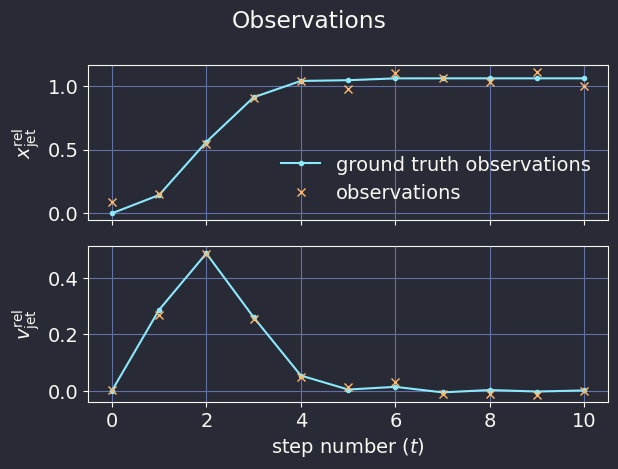

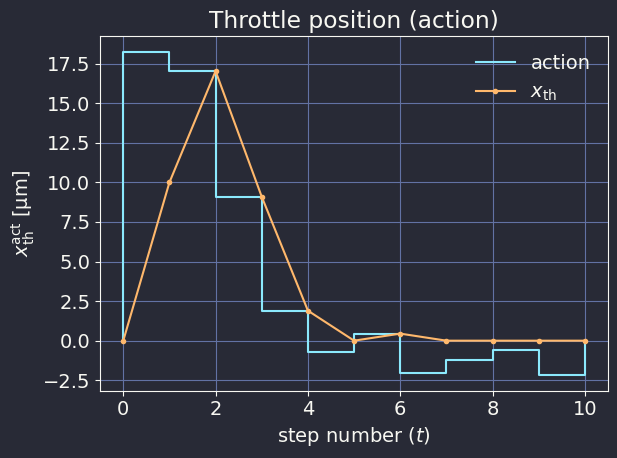


SEED = 4
Total objective: 1.96329
log folder: ./data/P_controller/2025-09-03_194903_3_state_seed_4


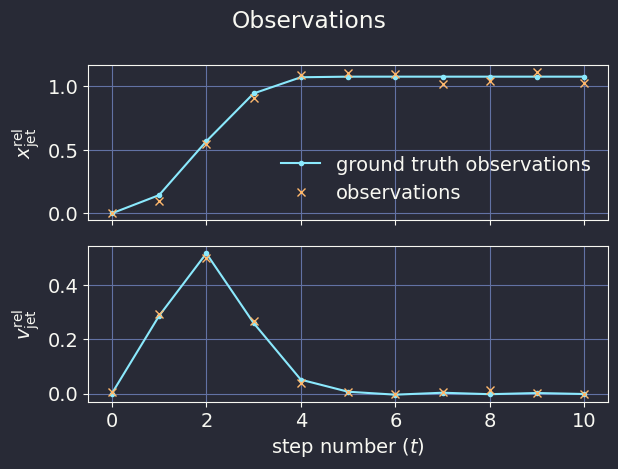

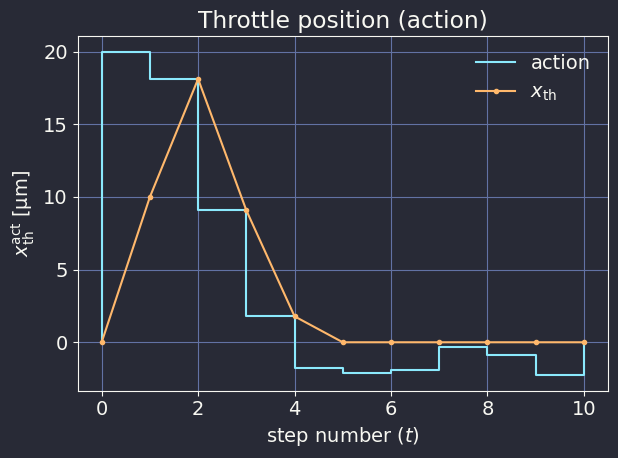


SEED = 5
Total objective: 1.99854
log folder: ./data/P_controller/2025-09-03_194903_3_state_seed_5


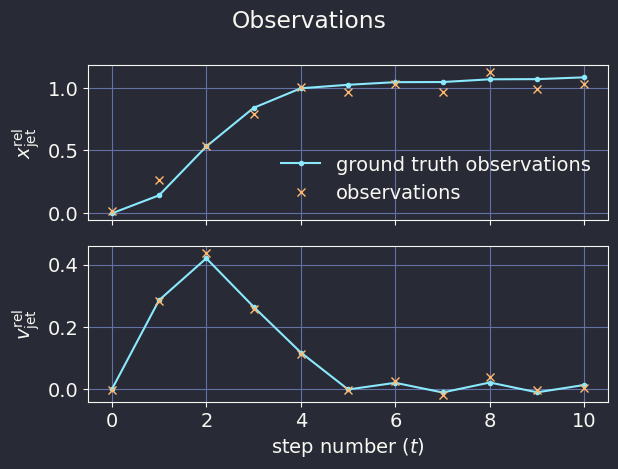

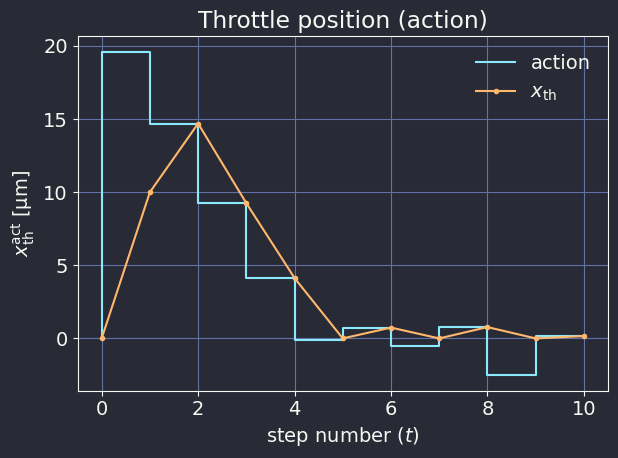


SEED = 6
Total objective: 2.02012
log folder: ./data/P_controller/2025-09-03_194903_3_state_seed_6


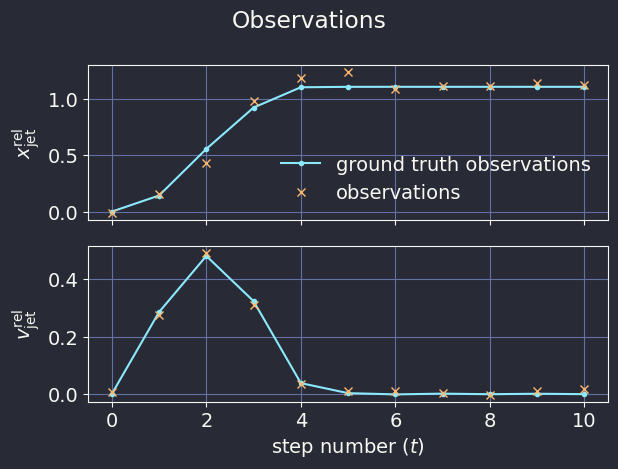

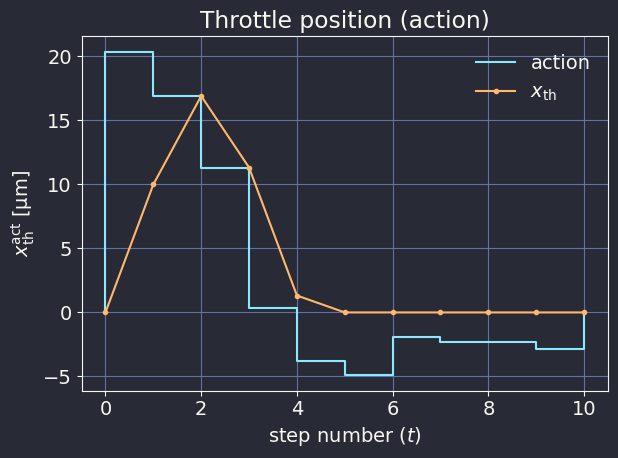


SEED = 7
Total objective: 1.95683
log folder: ./data/P_controller/2025-09-03_194903_3_state_seed_7


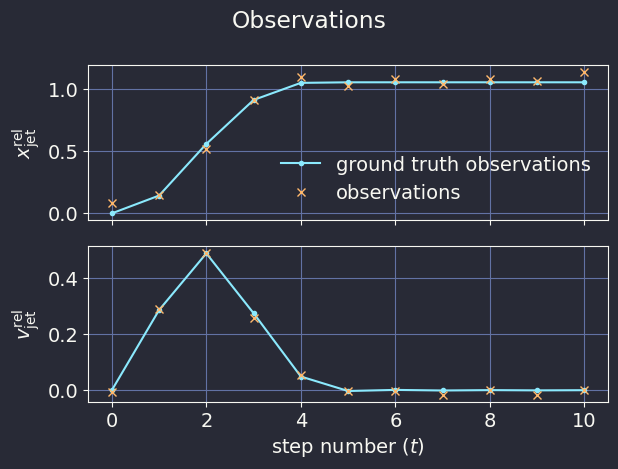

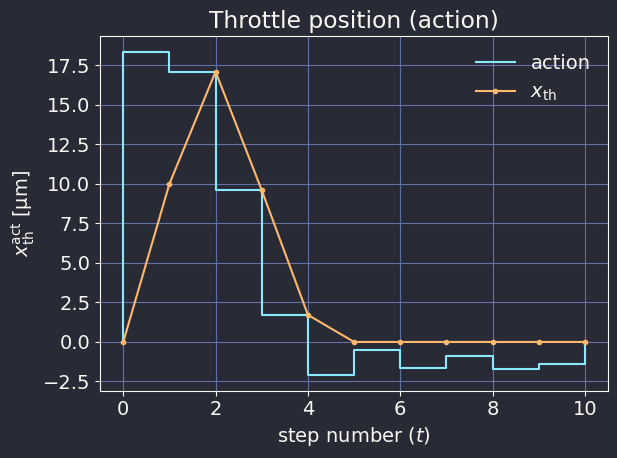


SEED = 8
Total objective: 2.06936
log folder: ./data/P_controller/2025-09-03_194903_3_state_seed_8


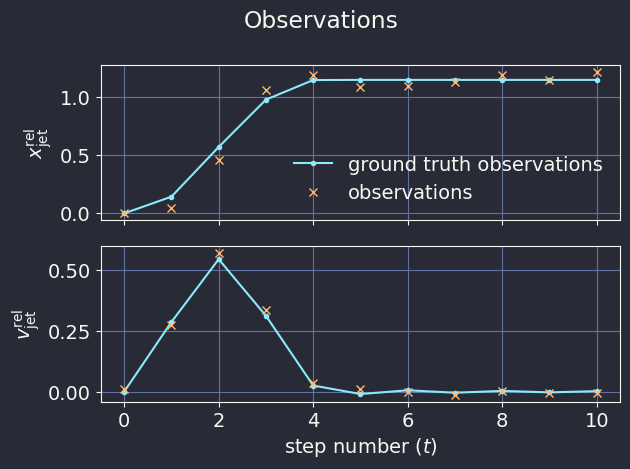

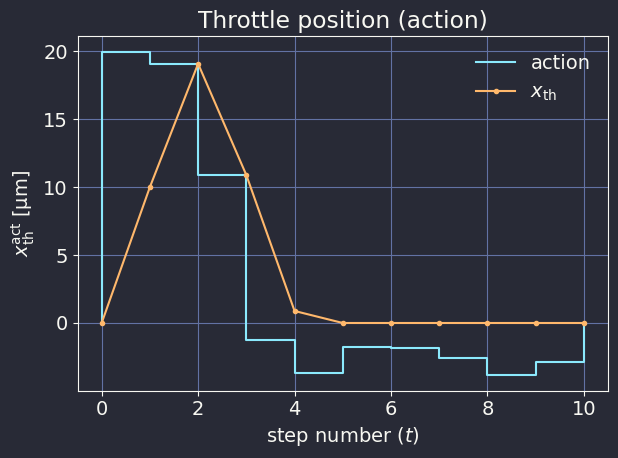


SEED = 9
Total objective: 1.97838
log folder: ./data/P_controller/2025-09-03_194903_3_state_seed_9


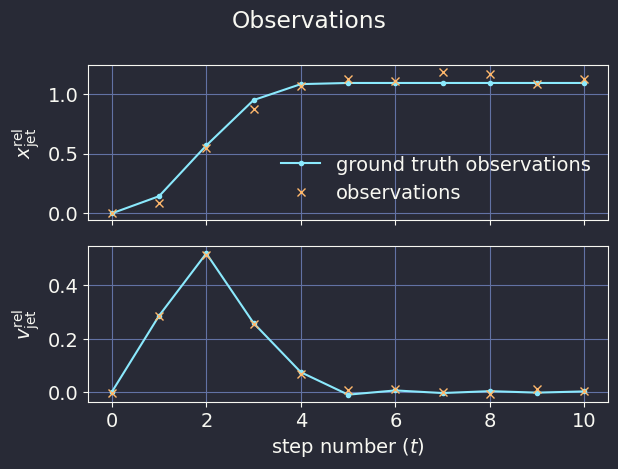

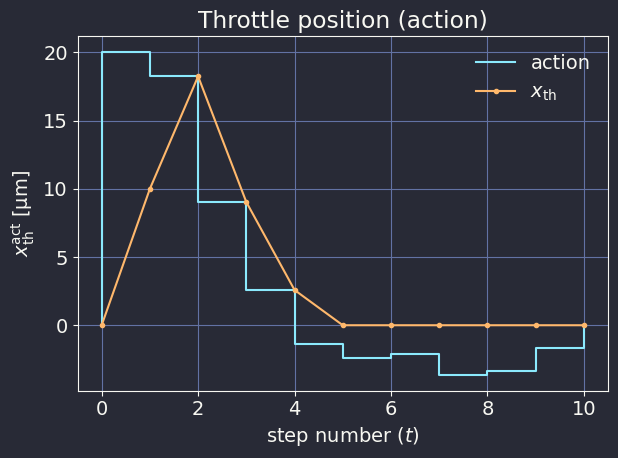


SEED = 10
Total objective: 1.95653
log folder: ./data/P_controller/2025-09-03_194903_3_state_seed_10


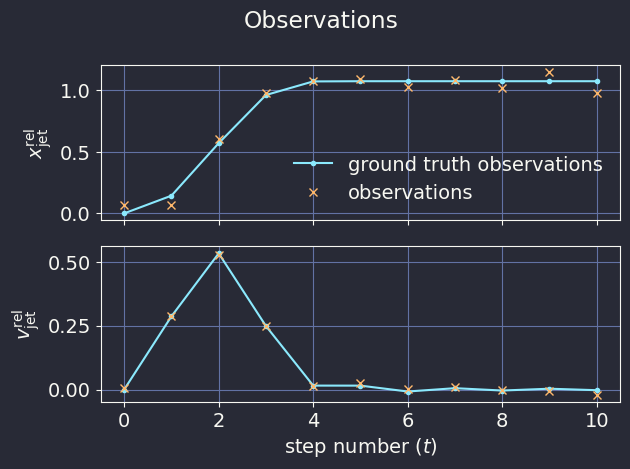

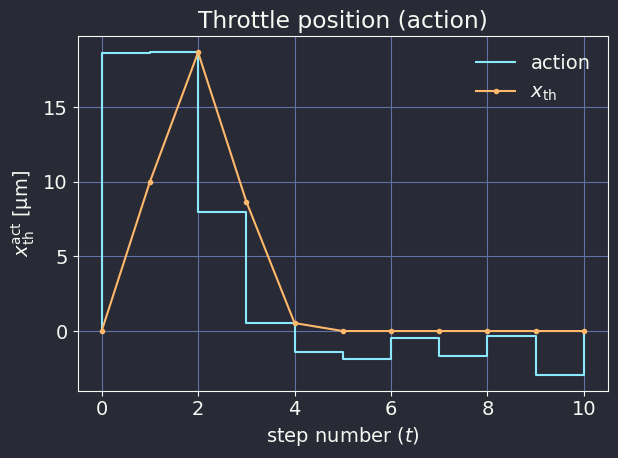


SEED = 11
Total objective: 1.95497
log folder: ./data/P_controller/2025-09-03_194903_3_state_seed_11


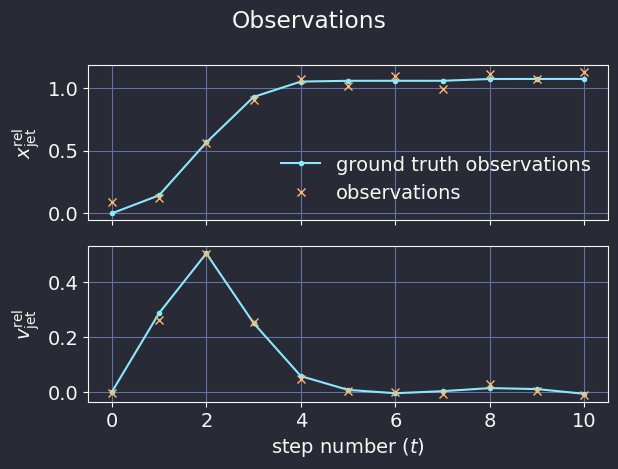

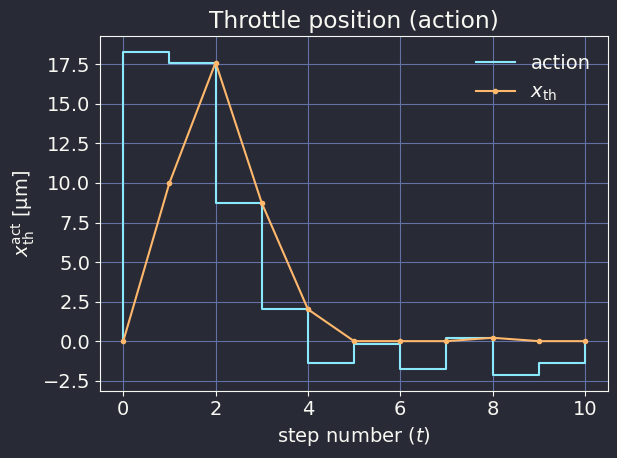


SEED = 12
Total objective: 1.94565
log folder: ./data/P_controller/2025-09-03_194903_3_state_seed_12


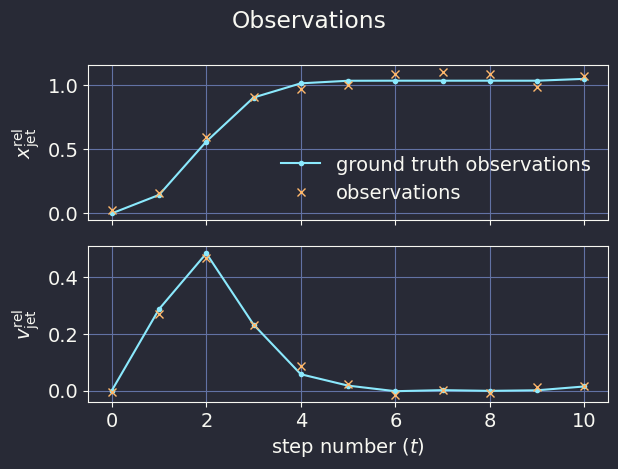

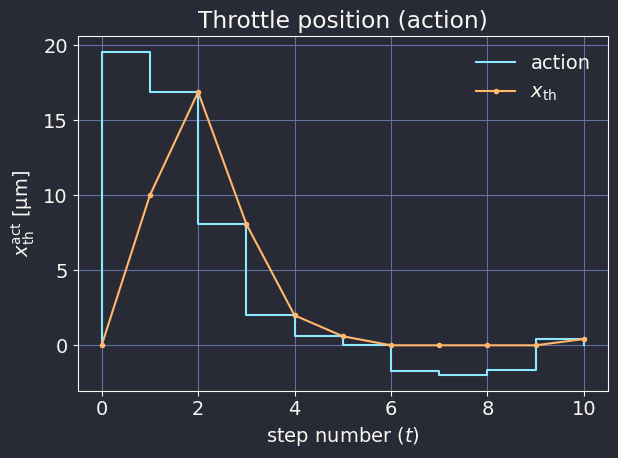


SEED = 13
Total objective: 1.93701
log folder: ./data/P_controller/2025-09-03_194903_3_state_seed_13


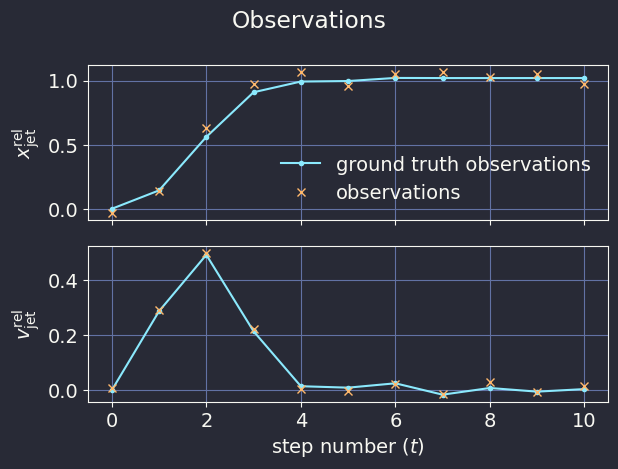

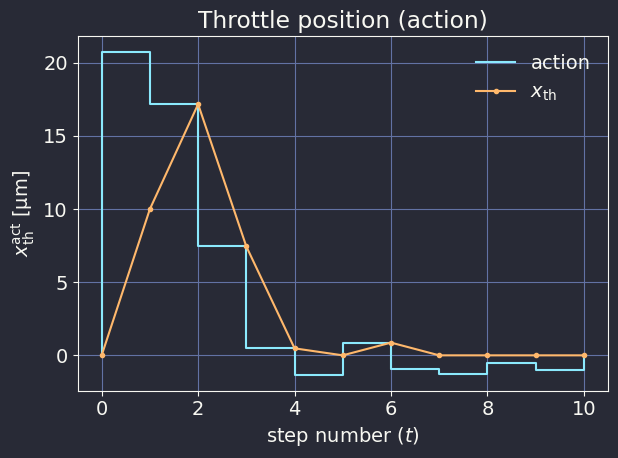


SEED = 14
Total objective: 2.01625
log folder: ./data/P_controller/2025-09-03_194903_3_state_seed_14


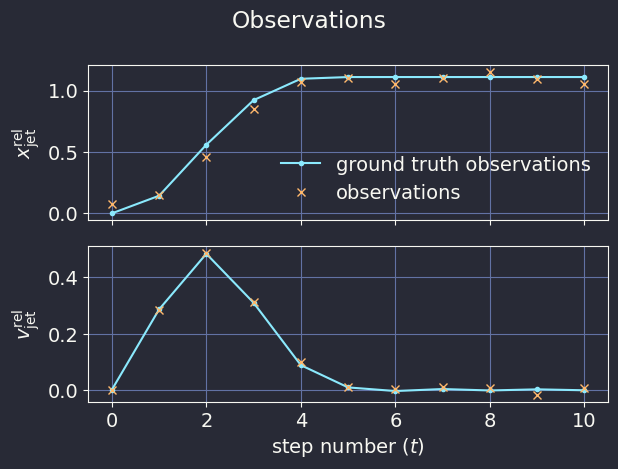

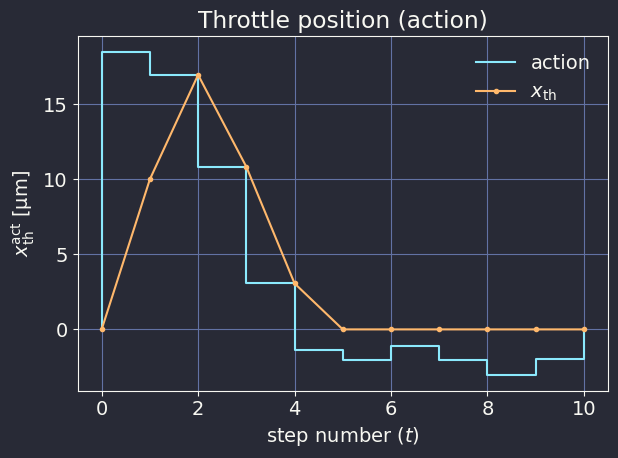

In [2]:
now = datetime.now()
dt_string = now.strftime("%Y-%m-%d_%H%M%S")
print(f'Time start: {dt_string}')

seed_list = list(range(1,15))
print(seed_list)

for SEED in seed_list:
    print()
    print(f'SEED = {SEED}')
    np.random.seed(SEED)
    random.seed(SEED)

    system = HydraulicSystem(
        jet_length_std=5e-2,
        jet_velocity_std=1e-2,
    )
    simulator = Simulator(system, N_steps=10, state_init=np.array([1e3, 0]))
    controller = PDController(
        P_coef=20,
        D_coef=0,
    )

    scenario = SimulationScenario(
        simulator=simulator,
        policy=controller,
        root_data_path=data_path,
        seed=SEED,
        dt_string=dt_string + '_3_state'
    )

    scenario.run()
    scenario.plot_data()